# Using mheapmap for visualizing unsupervised cell type clustering on Spatial Omics Datasets

In [1]:
# Additional dependencies: uv pip install scanpy squidpy igraph
!uv pip install scanpy squidpy igraph

Using Python 3.13.3 environment at: D:\Projects\mheatmap\.venv
Resolved 127 packages in 1.88s
Uninstalled 2 packages in 349ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 1.93s
 - pandas==3.0.1
 ~ pandas==2.3.3


In [2]:
import scanpy as sc
import squidpy as sq

import pandas as pd
import numpy as np
from scipy.sparse import issparse
from mheatmap import mosaic_heatmap, amc_postprocess, spectral_permute, rms_permute

d:\Projects\mheatmap\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Projects\mheatmap\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
d:\Projects\mheatmap\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
d:\Projects\mheatmap\.venv\Lib\site-packages\spatialdata\_core\query\relational_query.py:533: FutureWarning: functools.partial will be

In [3]:
# Load SpatialData object
adata = sq.datasets.visium_fluo_adata()

In [4]:
    # Spatial + Expression Graph construction
# nearest neighbor graph
# sc.pp.neighbors(adata)
nn_graph_genes = adata.obsp["connectivities"]
# spatial proximity graph
sq.gr.spatial_neighbors(adata)
nn_graph_space = adata.obsp["spatial_connectivities"]

alpha = 0.2 # Mixing param
joint_graph = (1 - alpha) * nn_graph_genes + alpha * nn_graph_space

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


In [5]:
# Util functions for automatic param finding
def compute_modularity_components(A, labels):
    """
    Compute f1 (intra-cluster edge density) and f2 (degree concentration)
        
    Parameters:
    -----------
    A : sparse matrix
        Adjacency matrix (connectivities)
    labels : array
        Cluster labels for each node
        
    Returns:
    --------
    f1 : float - Sum of intra-cluster edge densities
    f2 : float - Sum of squared degree concentration
    """
    if issparse(A):
        A = A.tocsr()
    m = A.sum() / 2.0
    if m == 0:
        return 0.0, 1.0
    k = np.array(A.sum(axis=1)).flatten()
    unique_clusters = np.unique(labels)
    e_cc_values, a_c2_values = [], []
    for cid in unique_clusters:
        idx = np.where(labels == cid)[0]
        if len(idx) == 0:
            continue
        A_c = A[idx, :][:, idx]
        e_cc = A_c.sum() / (2.0 * m)
        e_cc_values.append(e_cc)
        a_c = k[idx].sum() / (2.0 * m)
        a_c2_values.append(a_c ** 2)
    return float(np.sum(e_cc_values)), float(np.sum(a_c2_values))

def evaluate_resolution(adata, A, resolution, key_prefix="leiden_res", random_state=42):
    """Run Leiden and compute f1/f2 for a given resolution"""
    key_name = f"{key_prefix}_{resolution:.6f}"
    sc.tl.leiden(adata, adjacency=A, resolution=resolution,
                key_added=key_name, random_state=random_state, flavor="igraph")
    labels = adata.obs[key_name].astype(int).values
    n_clusters = np.unique(labels).size
    f1, f2 = compute_modularity_components(A, labels)
    return {
        "resolution": resolution,
        "f1": f1,
        "f2": f2,
        "n_clusters": int(n_clusters),
        "labels": labels,
        "key_name": key_name
    }

def evaluate_optim(coords):
    """Evalute the performance of a resolution based on Pareto front criteria;
    The larger the returned the distance is, the better is the resolution."""
    # Theoretical endpoints: (0,0) -> (1,1)
    start = np.array([0.0, 0.0])
    end = np.array([1.0, 1.0])

    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len

    vec_to_point = coords - start
    proj_length = np.dot(vec_to_point, line_unitvec)
    proj_point = start + proj_length * line_unitvec
    dist = np.linalg.norm(coords - proj_point)

    return dist

def evaluate_improvement(point_D, point_A, point_B, tolerance=1e-4):
    """Evaluate if the new point (D) expands the Pareto front between (A, D)"""
    f1_A, f2_A = point_A['f1'], point_A['f2']
    f1_B, f2_B = point_B['f1'], point_B['f2']
    f1_D, f2_D = point_D['f1'], point_D['f2']

    delta_f1 = f1_B - f1_A
    delta_f2 = f2_B - f2_A
    
    if abs(delta_f1) < 1e-10 and abs(delta_f2) < 1e-10:
        return False, 0.0
    
    a = delta_f2
    b = -delta_f1
    c = delta_f1 * f2_A - delta_f2 * f1_A
    
    distance = abs(a * f1_D + b * f2_D + c) / np.sqrt(a**2 + b**2)
    is_between = (min(f1_A, f1_B) <= f1_D <= max(f1_A, f1_B))
    is_better = (distance > tolerance) and is_between
    
    return is_better

def search_pareto_front(adata, A, delta_min, delta_max, max_depth=5, 
                    tolerance=1e-4, random_state=42, verbose=False):
    """Complete Pareto front search algorithm"""
    all_points = []
        
    # Evaluate endpoints
    point_min = evaluate_resolution(adata, A, delta_min, random_state)
    point_max = evaluate_resolution(adata, A, delta_max, random_state)
    all_points.extend([point_min, point_max])
        
    # Recursive search
    def recursive_search(point_A, point_B, depth=0):
        if depth >= max_depth:
            return []
                
        if abs(point_B['resolution'] - point_A['resolution']) < tolerance:
            return []
                
        delta_new = (point_B['resolution'] + point_A['resolution']) / 2 # Use midpoint
                
        if delta_new is None:
            return []
                
        try:
            point_new = evaluate_resolution(adata, A, delta_new, random_state)
        except Exception:
            return []
                
        is_better = evaluate_improvement(point_new, point_A, point_B, tolerance)
                
        new_points = []
        if is_better:
            new_points.append(point_new)
            new_points.extend(recursive_search(point_A, point_new, depth + 1))
            new_points.extend(recursive_search(point_new, point_B, depth + 1))
                
        return new_points
        
    new_points = recursive_search(point_min, point_max, depth=0)
    all_points.extend(new_points)
        
    return sorted(all_points, key=lambda p: p['resolution'])

def find_knee_point(pareto_points):
    """Find the knee point on the Pareto front using distance from diagonal"""
    f1_arr = np.array([p['f1'] for p in pareto_points])
    f2_arr = np.array([p['f2'] for p in pareto_points])
        
    coords = np.column_stack([f1_arr, f2_arr])
        
    # Theoretical endpoints: (0,0) -> (1,1)
    start = np.array([0.0, 0.0])
    end = np.array([1.0, 1.0])
        
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len
        
    distances = []
    for point in coords:
        dist = evaluate_optim(point)
        distances.append(dist)
        
    knee_idx = np.argmax(distances)
    return pareto_points[knee_idx]

[{'resolution': 0.75, 'f1': 0.935522198677063, 'f2': 0.07763165235519409, 'n_clusters': 16, 'labels': array([0, 1, 2, ..., 5, 5, 5], shape=(2800,)), 'key_name': '42_0.750000'}, {'resolution': 0.875, 'f1': 0.933396577835083, 'f2': 0.0747683197259903, 'n_clusters': 17, 'labels': array([0, 1, 2, ..., 5, 5, 5], shape=(2800,)), 'key_name': '42_0.875000'}, {'resolution': 0.9375, 'f1': 0.9318526983261108, 'f2': 0.07342511415481567, 'n_clusters': 17, 'labels': array([0, 1, 2, ..., 5, 5, 5], shape=(2800,)), 'key_name': '42_0.937500'}, {'resolution': 1.0, 'f1': 0.9271767139434814, 'f2': 0.06839264929294586, 'n_clusters': 19, 'labels': array([0, 1, 2, ..., 5, 5, 5], shape=(2800,)), 'key_name': '42_1.000000'}, {'resolution': 1.0625, 'f1': 0.9262444376945496, 'f2': 0.06713560223579407, 'n_clusters': 19, 'labels': array([0, 1, 2, ..., 5, 5, 5], shape=(2800,)), 'key_name': '42_1.062500'}, {'resolution': 1.078125, 'f1': 0.9216282367706299, 'f2': 0.0627642497420311, 'n_clusters': 20, 'labels': array([0

d:\Projects\mheatmap\.venv\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
d:\Projects\mheatmap\.venv\Lib\site-packages\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


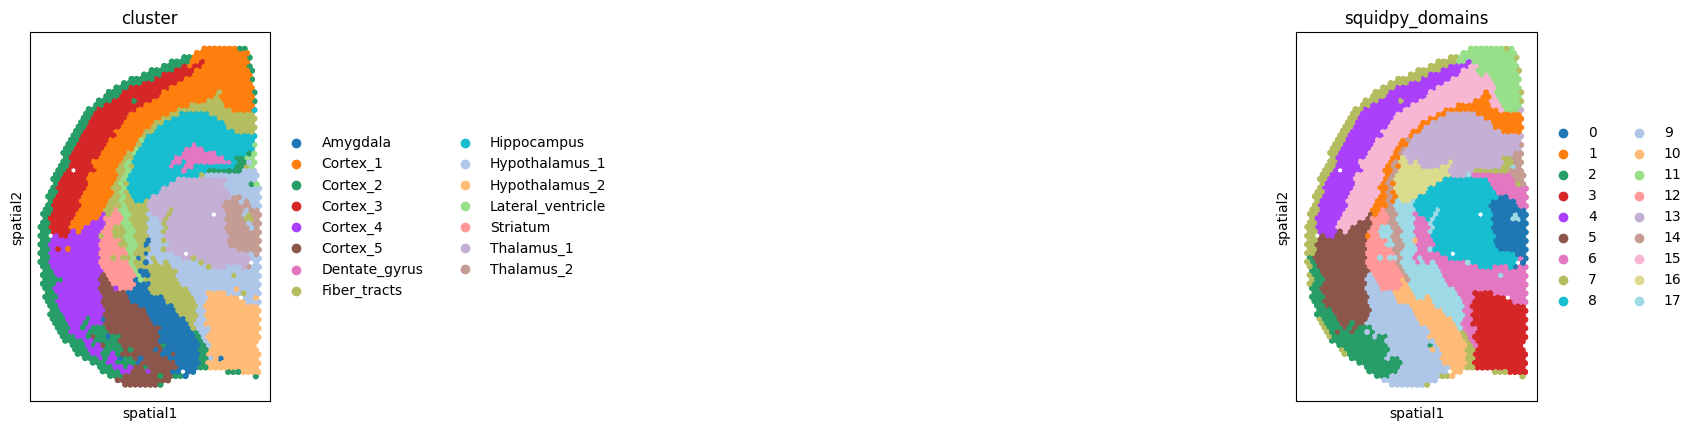

In [6]:
# Run Leiden with automatic param finding by modularity
A = adata.obsp["connectivities"]
candidates = search_pareto_front(adata, A, 0.75, 1.25, 10)
print(candidates)
optim = find_knee_point(candidates)
print(optim)

sc.tl.leiden(adata, adjacency=joint_graph, key_added="squidpy_domains", random_state=42, flavor='igraph', resolution=optim['resolution'])
sq.pl.spatial_scatter(adata, color=["cluster", "squidpy_domains"], shape=None, wspace=0.9, spatial_key='spatial', library_id='obsm')

In [7]:
adata.obs["cluster"]

AAACAAGTATCTCCCA-1        Thalamus_2
AAACAGAGCGACTCCT-1      Fiber_tracts
AAACAGTGTTCCTGGG-1          Cortex_2
AAACATTTCCCGGATT-1    Hypothalamus_2
AAACCGGGTAGGTACC-1          Cortex_3
                           ...      
TTGTTCAGTGTGCTAC-1       Hippocampus
TTGTTGTGTGTCAAGA-1        Thalamus_1
TTGTTTCACATCCAGG-1          Cortex_4
TTGTTTCATTAGTCTA-1          Cortex_4
TTGTTTCCATACAACT-1          Cortex_4
Name: cluster, Length: 2800, dtype: category
Categories (15, object): ['Amygdala', 'Cortex_1', 'Cortex_2', 'Cortex_3', ..., 'Lateral_ventricle', 'Striatum', 'Thalamus_1', 'Thalamus_2']

In [8]:
adata.obs["squidpy_domains"]

AAACAAGTATCTCCCA-1     0
AAACAGAGCGACTCCT-1     1
AAACAGTGTTCCTGGG-1     2
AAACATTTCCCGGATT-1     3
AAACCGGGTAGGTACC-1     4
                      ..
TTGTTCAGTGTGCTAC-1    13
TTGTTGTGTGTCAAGA-1     8
TTGTTTCACATCCAGG-1     5
TTGTTTCATTAGTCTA-1     5
TTGTTTCCATACAACT-1     5
Name: squidpy_domains, Length: 2800, dtype: category
Categories (18, object): ['0', '1', '2', '3', ..., '14', '15', '16', '17']

<Axes: xlabel='squidpy_domains', ylabel='cluster'>

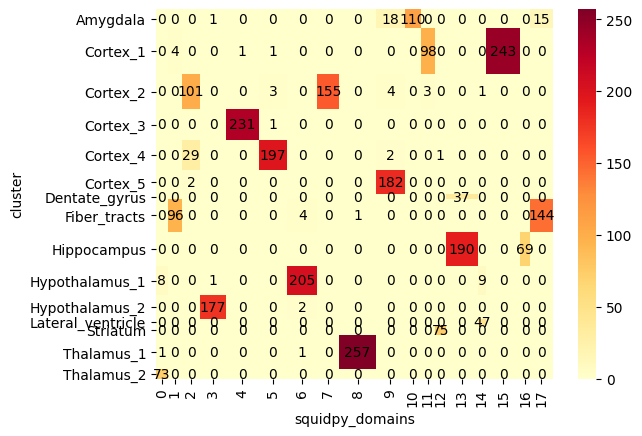

In [9]:
# Visualize with mheatmap
cmat = pd.crosstab(adata.obs["cluster"], adata.obs["squidpy_domains"]) # Build Contingency Table (Row: Ground Truth, Column: Prediction)
mosaic_heatmap(cmat, annot=True, fmt='d', cmap='YlOrRd')

<Axes: >

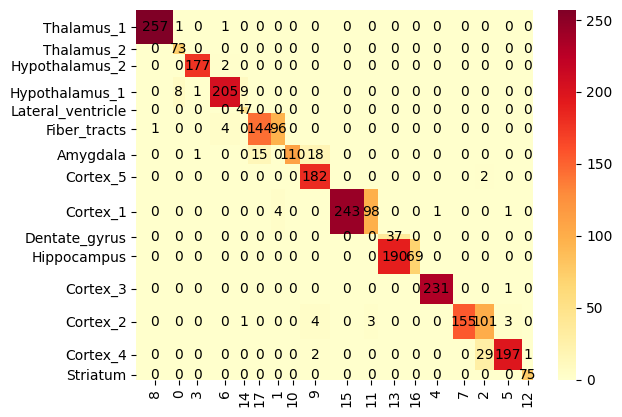

In [10]:
# Spectral Permute and Visualization

gt = adata.obs["cluster"]
pred = adata.obs["squidpy_domains"]

# Build Contingency Table (Row: Ground Truth, Column: Prediction)
cmat = pd.crosstab(gt, pred)

# Get row and column labels
row_labels = np.asarray(cmat.index)
col_labels = np.asarray(cmat.columns)

# Spectral Reordering with column permutation support (works for rectangular matrices in mode='tw')
result = spectral_permute(cmat.to_numpy(), row_labels, mode='tw', col_labels=col_labels)

# Visualize reordered matrix with correct labels
reordered_cmat = pd.DataFrame(
    result.reordered_matrix,
    index=result.reordered_row_labels,
    columns=result.reordered_col_labels
)
mosaic_heatmap(reordered_cmat, annot=True, fmt='d', cmap='YlOrRd')